# I. Data preparation

Loading data from source

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pathlib
import tensorflow.keras.layers as tfl
import os
import pickle
import keras_tuner as kt

In [3]:
from zipfile import ZipFile

# uncomment to load data
# zip_dir = 'data/emotion_data.zip'
# extraction_dir = ""

# with ZipFile(zip_dir, 'r') as zip_object:
#     zip_object.extractall(path=extraction_dir)

# print(f"All files extracted from '{zip_dir}' to '{extraction_dir}'.")

data_dir = pathlib.Path("emotion_data/")

Viewing training data

In [4]:
num_train_images = len(list(data_dir.glob("train/*/*")))
print("Images:", num_train_images)
print("Classes:", list(data_dir.glob("train/*")))

Images: 28709
Classes: [WindowsPath('emotion_data/train/angry'), WindowsPath('emotion_data/train/disgust'), WindowsPath('emotion_data/train/fear'), WindowsPath('emotion_data/train/happy'), WindowsPath('emotion_data/train/neutral'), WindowsPath('emotion_data/train/sad'), WindowsPath('emotion_data/train/surprise')]


In [5]:
train_dir = pathlib.Path("emotion_data/train")

batch_size = 64
# img_height = 180
# img_width = 180
val_split = 0.2

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=val_split,
    subset="both",
    seed=91,
    image_size=(48,48),
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=True,
    label_mode='categorical'
)
# train_ds = train_ds.shuffle(buffer_size=len(list(train_ds.as_numpy_iterator())))
# val_ds = val_ds.shuffle(buffer_size=len(list(val_ds.as_numpy_iterator())))

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Using 5741 files for validation.


## Training preparation

In [6]:
class_names = train_ds.class_names
image_shape = None
labels_shape = None
num_classes = len(class_names)

for image_batch, labels_batch in train_ds:
    image_shape = image_batch.shape[1:]
    labels_shape = labels_batch.numpy().shape[1:]
    print(image_batch, labels_batch)
    break

print(class_names, image_shape, labels_shape)

tf.Tensor(
[[[[ 10.  10.  10.]
   [  6.   6.   6.]
   [  7.   7.   7.]
   ...
   [  2.   2.   2.]
   [  4.   4.   4.]
   [  1.   1.   1.]]

  [[ 10.  10.  10.]
   [  8.   8.   8.]
   [  9.   9.   9.]
   ...
   [  2.   2.   2.]
   [  3.   3.   3.]
   [  2.   2.   2.]]

  [[ 10.  10.  10.]
   [  9.   9.   9.]
   [  8.   8.   8.]
   ...
   [  2.   2.   2.]
   [  1.   1.   1.]
   [  2.   2.   2.]]

  ...

  [[  5.   5.   5.]
   [  0.   0.   0.]
   [ 81.  81.  81.]
   ...
   [119. 119. 119.]
   [139. 139. 139.]
   [139. 139. 139.]]

  [[  2.   2.   2.]
   [  8.   8.   8.]
   [  8.   8.   8.]
   ...
   [132. 132. 132.]
   [133. 133. 133.]
   [137. 137. 137.]]

  [[  0.   0.   0.]
   [ 14.  14.  14.]
   [  0.   0.   0.]
   ...
   [132. 132. 132.]
   [134. 134. 134.]
   [129. 129. 129.]]]


 [[[103. 103. 103.]
   [103. 103. 103.]
   [100. 100. 100.]
   ...
   [ 33.  33.  33.]
   [ 23.  23.  23.]
   [ 21.  21.  21.]]

  [[104. 104. 104.]
   [103. 103. 103.]
   [ 99.  99.  99.]
   ...
   [ 47.  

Dataset configuration

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

subset_reduction_factor_train = 0.2
subset_reduction_factor_val = 0.2
num_batches = num_train_images//batch_size

train_subset_size = int(num_batches*(1-val_split)*subset_reduction_factor_train)
val_subset_size = int(num_batches*val_split*subset_reduction_factor_val)

used_train_ds = train_ds.cache().take(train_subset_size).prefetch(buffer_size=AUTOTUNE)
used_val_ds = val_ds.cache().take(val_subset_size).prefetch(buffer_size=AUTOTUNE)

train_subset_size, val_subset_size

(71, 17)

# 2. Training

## Utilities

### Save/load utilities

Every time a distinct model is trained and/or used for observations, call `set_save_paths(model_name: str)`. Use the paths `checkpoint_path` and `base_path`, as well as the subroutines below, accordingly.

Information that can be saved and loaded are the training history and the parameters of a model.

By default, models load pretrained weights. Cells containing `model.fit()` can be optionally run once or multiple times by changing the cell format from raw to Python.

To train a fresh model, delete/rename the `training` folder (or its specific subfolders)

In [8]:
base_path:str = None
checkpoint_path:str = None
current_model_name:str = None

In [9]:
def create_path(filepath, isfile=True):
    path = pathlib.Path(filepath)
    if isfile:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.touch(exist_ok=True)
    else:
        path.mkdir(parents=True, exist_ok=True)

def set_save_paths(model_name:tf.keras.Model):
    global checkpoint_path
    global base_path
    global current_model_name
    current_model_name = model_name
    base_path = f"training/{model_name}"
    checkpoint_path = f"{base_path}/parameters.weights.h5"
    print("Save path now belongs to", current_model_name)

def load_parameters(model, custom_model_name=None):
    global checkpoint_path
    global base_path
    global current_model_name

    used_model_name = custom_model_name if custom_model_name != None else current_model_name
    used_checkpoint_path = f"training/{used_model_name}/parameters.weights.h5"

    if not os.path.isfile(used_checkpoint_path):
        print("No parameters found, no parameters loaded from", used_model_name)
        return

    print("Loading parameters of", used_model_name, f"({'Custom' if custom_model_name != None else 'Default'})")

    model.load_weights(used_checkpoint_path, skip_mismatch=True)

def save_object(object, name="history"):
    global checkpoint_path
    global base_path
    global current_model_name

    path = f"{base_path}/{name}"

    create_path(path, isfile=False)

    all_items = os.listdir(path)
    files_only = [os.path.join(path, item) for item in all_items]
    files_only = [item for item in files_only if os.path.isfile(item)]
    
    filepath = f"{path}/{len(files_only)}.pickle"
    create_path(filepath)
    
    print(f"Saving {name} of", current_model_name)
    with open(filepath, 'wb') as f:
        pickle.dump(object.history if name=="history" else object, f)

def load_object(name="history"):
    global checkpoint_path
    global base_path
    global current_model_name
    
    path = f"{base_path}/{name}"

    print(f"Loading {name} of", current_model_name)
    histories = []
    for i in os.listdir(path):
        curpath = os.path.join(path, i)
        if not os.path.isfile(curpath):
            continue
        with open(curpath, 'rb') as f:
            histories.append(pickle.load(f))
    return histories

def plot_object(chosen_attributes, ylim1=0, ylim2=1, name="history"):
    objects = load_object(name)
    for i in chosen_attributes:
        attribute_list = [item for cur_object in objects for item in cur_object[i]]
        plt.plot(np.arange(len(attribute_list)), attribute_list, label=i)
    plt.legend()
    plt.ylim(ylim1, ylim2)
    plt.title(f"{name} of {current_model_name}")
    plt.show()

## Pipeline checks

### Basic

Save path now belongs to sanity_dataset
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1719 - loss: 2.3850 - val_accuracy: 0.2031 - val_loss: 4.7708
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2656 - loss: 5.3130 - val_accuracy: 0.1562 - val_loss: 4.4629
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2031 - loss: 5.3358 - val_accuracy: 0.1719 - val_loss: 3.8125
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1719 - loss: 4.1335 - val_accuracy: 0.2031 - val_loss: 2.1517
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3438 - loss: 2.2592 - val_accuracy: 0.2344 - val_loss: 3.3427
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2656 - loss: 2.9952 - val_accuracy: 0.1094 - val_loss: 3.3752
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1875 - loss: 2.8863 - val_accuracy: 0.1406 - val_loss: 2.7265
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3906 - loss: 2.3

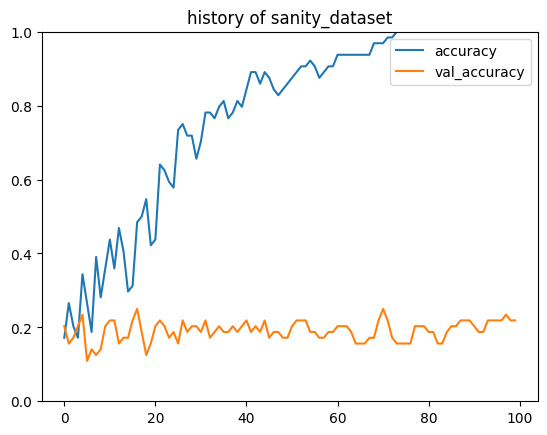

In [ ]:
set_save_paths("sanity_dataset")

# Tiny model
sanity_model = tf.keras.Sequential([
    tfl.Rescaling(1./255, input_shape=(48,48,3)),  # <--- SCALE INPUTS
    tfl.Flatten(),
    tfl.Dense(128, activation="relu"),
    tfl.Dense(num_classes, activation="softmax")
])

sanity_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

# Take just 1 batch from train and val
tiny_train = used_train_ds.take(1)
tiny_val = used_val_ds.take(1)

history = sanity_model.fit(
    tiny_train,
    validation_data=tiny_val,
    steps_per_epoch=1,
    validation_steps=1,
    epochs=100,
    verbose=1
)

save_object(history, name="history")

plot_object(
    chosen_attributes=["accuracy", "val_accuracy"],
    ylim1=0, ylim2=1,
    name="history")

Loading history of sanity_dataset


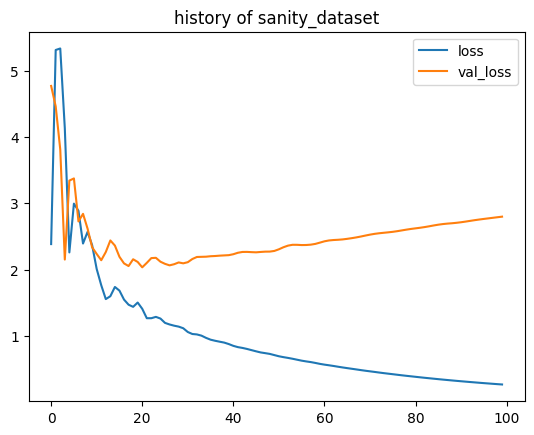

In [36]:
plot_object(
    chosen_attributes=["loss", "val_loss"], ylim1=None, ylim2=None,
    name="history")

### Transfer

In [42]:
set_save_paths("sanity_transfer")

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=image_shape,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=image_shape)
L = tfl.Rescaling(1./255)(inputs)
L = base_model(L, training=False)
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(64, activation="relu")(L)
outputs = tfl.Dense(num_classes, activation="softmax")(L)

sanity_transfer_model = tf.keras.Model(inputs, outputs)

sanity_transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

tiny_train = used_train_ds.take(1)
tiny_val   = used_val_ds.take(1)

history = sanity_transfer_model.fit(
    tiny_train,
    validation_data=tiny_val,
    steps_per_epoch=1,
    validation_steps=1,
    epochs=300,
    verbose=1
)

save_object(history, name="history")

Save path now belongs to sanity_transfer
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.1562 - loss: 2.4911 - val_accuracy: 0.1875 - val_loss: 2.1462
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.1250 - loss: 2.1653 - val_accuracy: 0.2031 - val_loss: 1.9653
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.1250 - loss: 1.9706 - val_accuracy: 0.2500 - val_loss: 1.8817
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.2656 - loss: 1.8787 - val_accuracy: 0.2500 - val_loss: 1.8570
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.2656 - loss: 1.8499 - val_accuracy: 0.2500 - val_loss: 1.8600
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.2656 - loss: 1.8438 - val_accuracy: 0.2500 - val_loss: 1.8648
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.2656 - loss: 1.8398 - val_accuracy: 0.2500 - val_loss: 1.8722
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.2812 -

Loading history of sanity_transfer


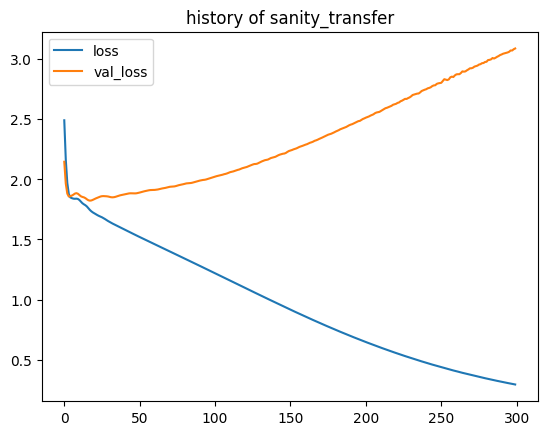

Loading history of sanity_transfer


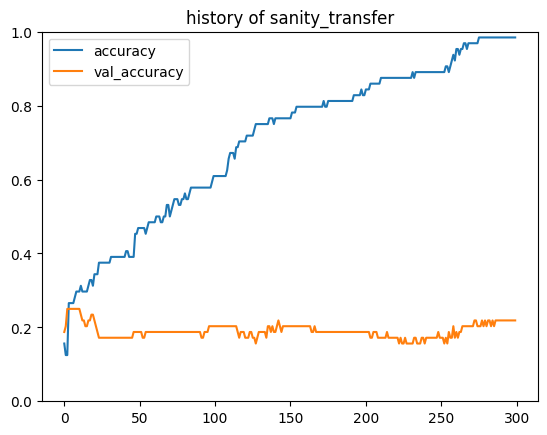

In [43]:
plot_object(
    chosen_attributes=["loss", "val_loss"],
    ylim1=None, ylim2=None,
    name="history")
plot_object(
    chosen_attributes=["accuracy", "val_accuracy"],
    ylim1=0, ylim2=1,
    name="history")